# Building a Synthetic Control Model with Lasso

Synthetic control models create a counterfactual outcome by combining untreated comparison units into a weighted average. Lasso regression is a powerful way to estimate these weights because it can shrink unimportant predictors to zero, reducing overfitting and improving interpretability.

## The Model
We model the treated unit as:

$Y_t = \beta_0 + \beta_1 * X_{1t} + \beta_2 * X_{2t} + ... + \beta_k * X_{kt} + \epsilon_{it}$

- $Y_t$ = outcome for the treated unit at time t
- $X_{it} ,..., X_{kt}$ = untreated comparison units at time t
- $\beta_0$ = The intercept from the model
- $\beta_1,... .., \beta_k$ = weights estimated from the data
- $\epsilon_{it}$ = error term

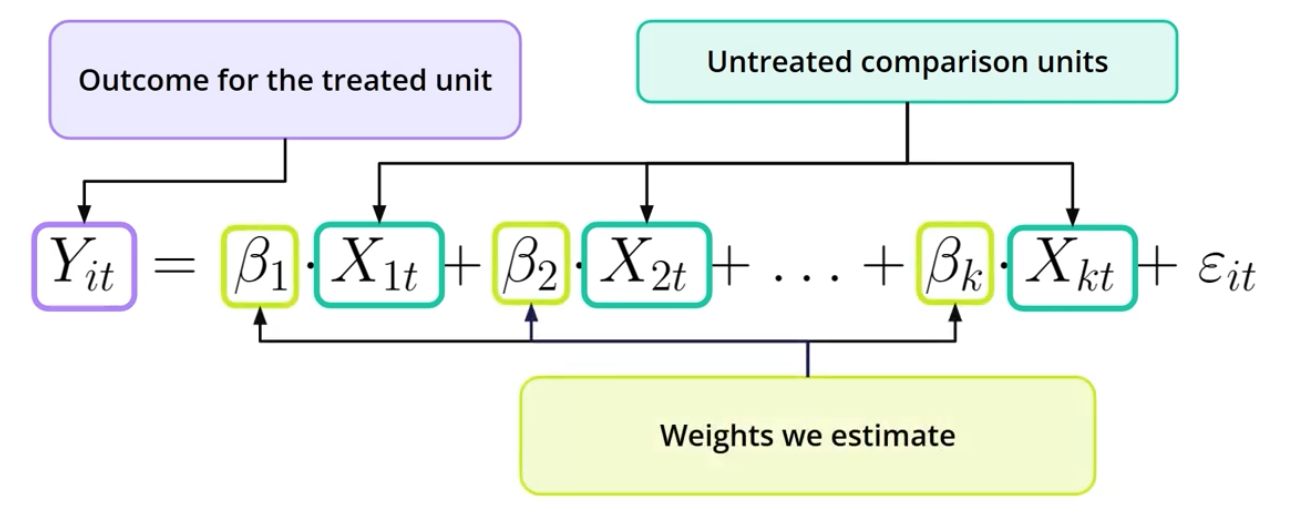

## Using Lasso regression:

- Coefficients on weak predictors are pushed toward zero
- Cross-validation tunes the penalty parameter $\alpha$
- The model avoids overfitting while identifying the most predictive controls

## Implementation Steps
- Train the model on pre-treatment data only.
- Apply weights to generate a synthetic control line for the treated unit.

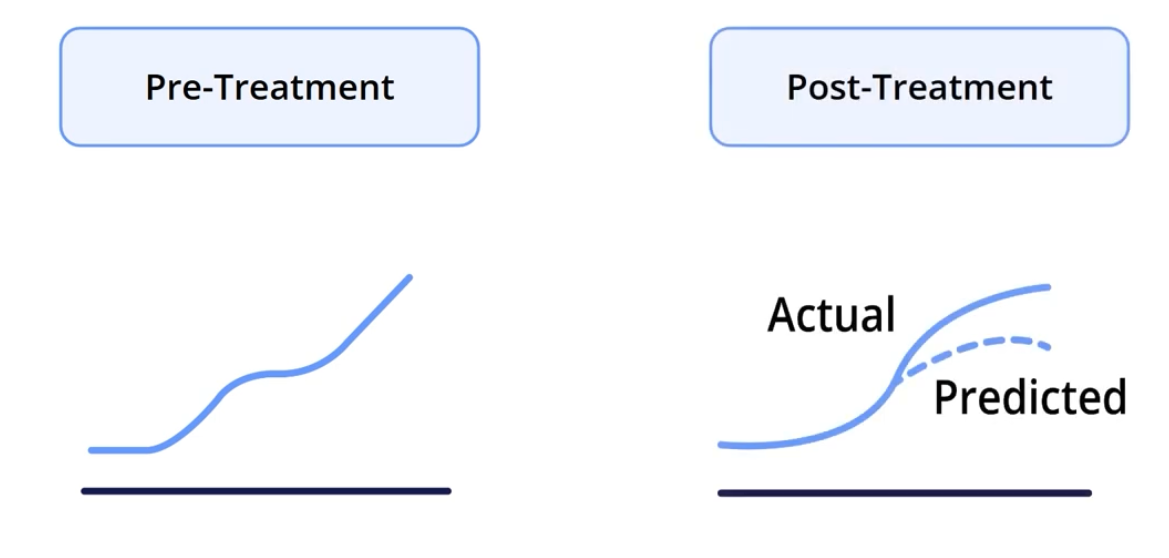

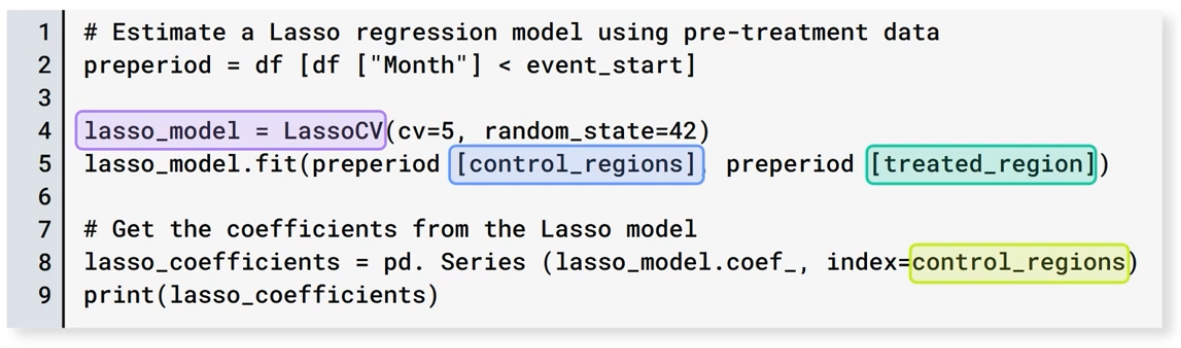

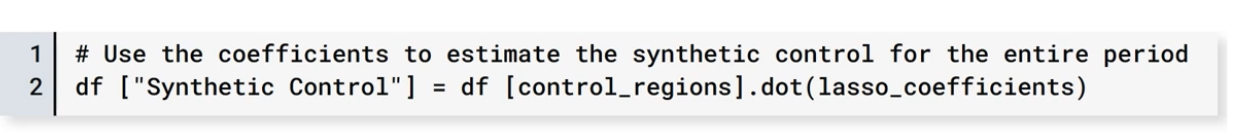
## Interpret results:
- Non-zero coefficients reveal which control units mattered

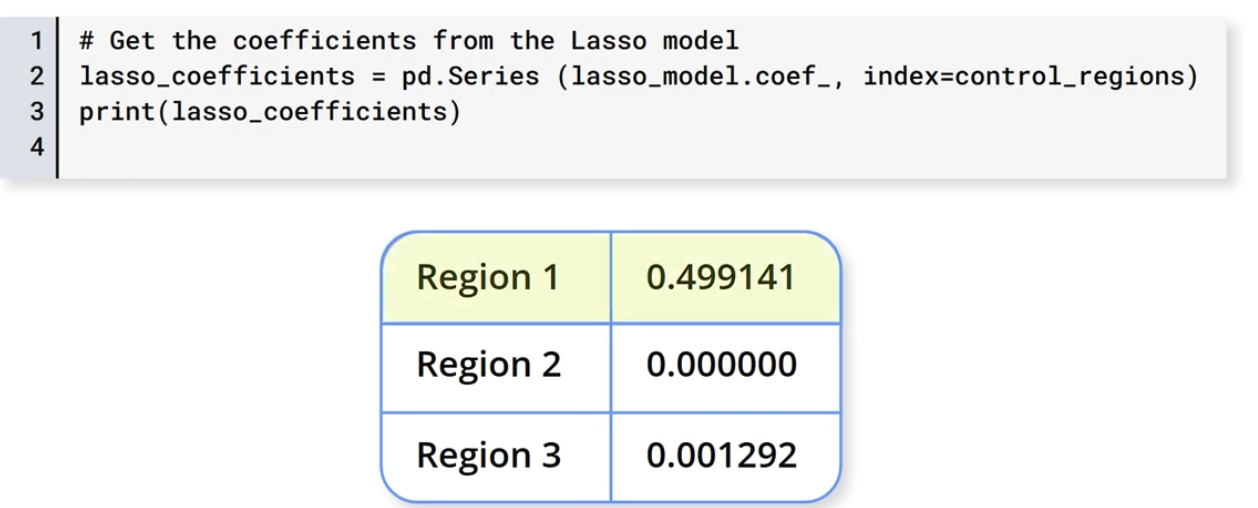
  
- Plot predicted vs. actual outcomes:
    - Good pre-treatment fit = strong credibility
    - Post-treatment gap = estimated treatment effect
        - **Note: Depending on the pre-treatment fit, you may need to net out pre-treatment average differences between the treated unit and synthetic control using methods such as difference-in-differences.** In this case, the intercept term effectively drops out of the analysis.

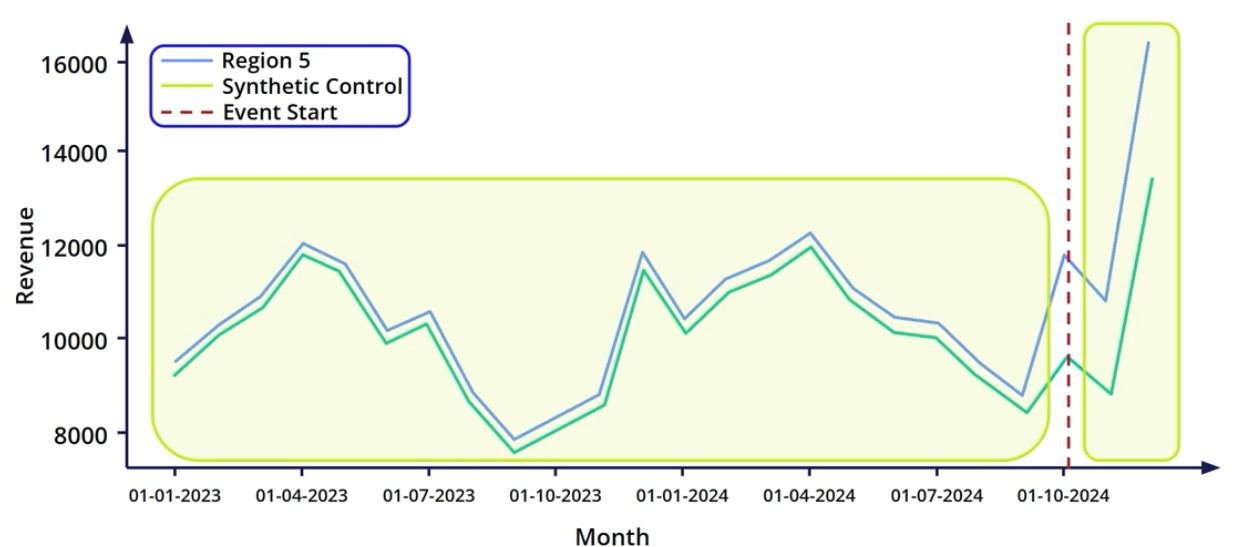

This is your first working synthetic control model. The next step is to validate its robustness with additional checks.

## Estimating Treatment Effects with Synthetic Control
Once we build a synthetic control, the next step is estimating the treatment effect. There are two common approaches:

1. Treat as a Difference-in-Differences
- Define a post-period indicator.
- Fit a simple DiD model where the treated unit is one group and the synthetic control is the other.
- The treated × post interaction term estimates the causal effect.
    - Note: this may underestimate uncertainty but provides a quick read.

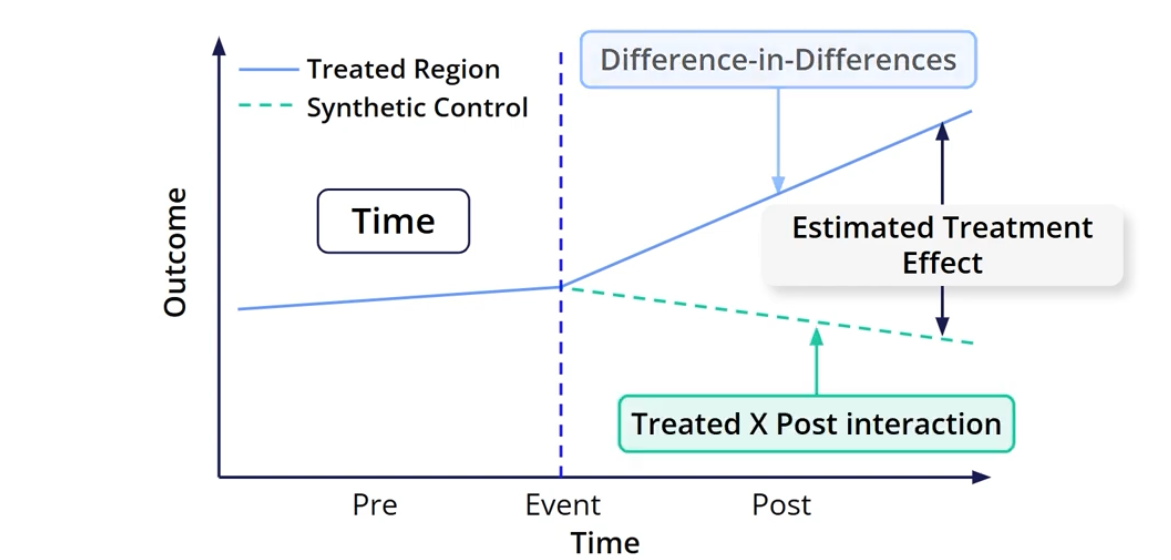

2. Placebo Tests
- For each untreated unit, pretend it was treated at the same time.
- Build a synthetic control for that unit and measure the post-treatment prediction gap. Be sure to drop the actual treated unit from the set of comparison units (aka the donor pool).
- Collect these gaps into a distribution of placebo effects—the range of results we’d expect by chance.
- Compare the real treated unit’s gap against this distribution.
- If it stands out (e.g., in the top 5%), it suggests the effect is real.

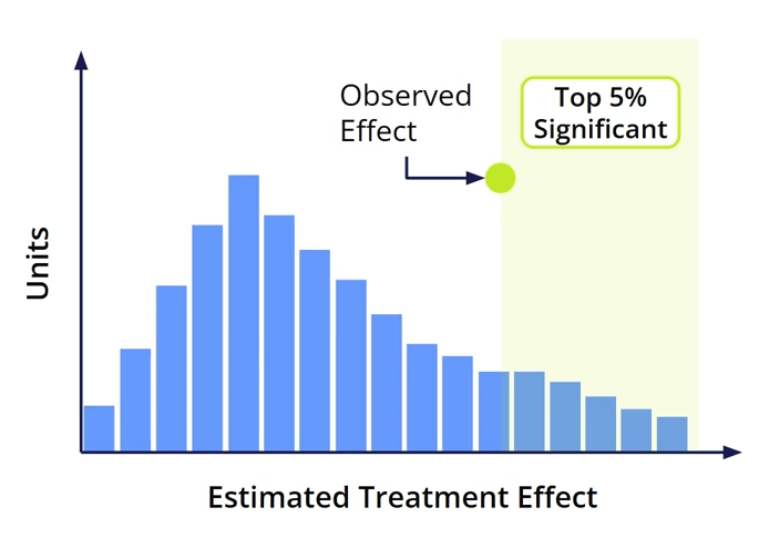

## Why This Matters
- Placebo testing is especially useful when:
    - There are few treated units, making direct comparisons hard.
    - Standard errors are difficult to define.
    - If very few untreated comparison units, you can try:
        - Assigning fake treatment dates prior to the actual one to get additional placebo effects
        - Using the mean and standard deviation of placebo estimates to construct a confidence interval.